In [1]:
import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path

##########################################################
# Initialize parameters  
##########################################################

#filename = "/data/fromlabpix/warm/packet-warm_pedestal-2025_10_28_13_40_41_PDT.h5" # all 5 tiles in B70 cryo. Warm. No channels disabled. Sync pulses
#filename = "/data/fromlabpix/cold/packet-cold_pedestal_5tiles_vdda1p8_nom-2025_10_30_12_16_02_PDT.h5" # Cold. 4 tiles. No channels disabled. Sync pulses
#filename = "../data/packet-warm_5tiles_tally_2025_11_05_12_49_59_PST.h5"
#filename = "../data/packet-warm_4tiles_tally_2025_11_19_09_23_21_PST.h5"

#set1-7 pedestal datafiles after disabling hot channels and links to bit-flipping chips
filename = "../results/set1-7/data/packet-warm_ped_150cycles_480s_7tiles_disable-hotchan-link_2026_1_9.hdf5"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7]

# serial numbers for set 1-7 (serial #s found on chip in upper left hand corner of tile)
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101' ]

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = False

# initialize datafile variables
nenabled_chips = 0
ig = 1 #this script can only run 1 io_group (and 1 tile) at a time
files = []
ndisabled_channels = [0 for chp in range(256)]
all_tile_incremental_diff = []
all_tile_max_differences = []
network = {}
debug_count = 0
first_tile = True

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def count_syncs(ts, receipt_ts):

    global list_n_syncs
    
    # initialize variables
    n_syncs = 0
    
    list_receipt_ts = receipt_ts.tolist()
    list_ts = ts.tolist()
    
    # a max_ts > 1E7 +1E5 most likely flags that a sync has been missed. The last packet might have had
    # extra ticks because the next sync pulse may have been slow-rising (i.e. triggered later
    # than is typical). In this function we only want to count the # of syncs received by chips that
    # do not miss any syncs
    if max(list_ts) < 1E7 + 1E5:

        # check each value to see if it is the max of a peak
        for i in range(len(list_ts)-1):        
        
            # this qualification signals a peak timestamp was found
            if list_ts[i+1] < list_ts[i]: 
                n_syncs += 1
    
        list_n_syncs.append(n_syncs)
        
    return
   

In [4]:
def check_syncs(ioch, tile, chip, ts, receipt_ts, base):

    global missing_sync_chip_count, sync_chips, max_10, debug_count, all_tile_incremental_diff
    global chip_serial_number, consecutive_missing_syncs, nsyncs, all_tile_max_differences

    # initialize variables
    missing, sync_received = 0, 0
    high_time = False
    diff_ts = []
    incremental_diff = []  
    max_clock_ts = 134217727 
    
    list_receipt_ts = receipt_ts.tolist()
    list_ts = ts.tolist()

    max_ts = max(list_ts)

    # when determining the difference between the 2 timestamps the absolute value will account for cases
    # where the receipt timestamp reset while the packet timestamp was already on its way to the pacman
    # i.e. the packet timestamp would be larger than the receipt ts. This would give a value that is close to
    # but not above 1E7
    for i in range(len(list_ts)):
        diff_ts.append(abs(list_receipt_ts[i] - list_ts[i]))
    
    # there should be a reasonably consistent difference between Receipt Timestamps and packet timestamps,
    # which accounts for the time to travel from chip to pacman. Δt greater than that amount indicates 
    # either missing syncs, slowly rising chip sync pulses, or the receipt timestamp
    # reset while the packet was traveling to the pacman. Subtract that consistent difference from Δt
    # to make resets or clock roll-overs more obvious
    min_dt = min(diff_ts) 
    for i in range(len(diff_ts)):
        incremental_diff.append(diff_ts[i] - min_dt)
    
    # store values for graphing
    max_differences.append(max(incremental_diff))
    sync_chips.append(chip)
    
    # a max_ts > 1E7 +1E5 most likely flags that a sync has been missed. The last packet might have had
    # extra ticks because the next sync pulse may have been slow-rising (i.e. triggered later
    # than is typical)
    if max_ts > 1E7 + 1E5:

        fig, axis = plt.subplots(1,2, figsize=(10, 3))
        axis[0].plot(list_ts)
        axis[0].set_title(f'Tile {tile} Chip {chip} Timestamps\nBenchtop test v3a Tile #{chip_serial_number}')
        axis[0].set_xlabel(f'Packets')
        axis[0].set_ylabel(f'Timestamp')

        missing_sync_chip_count +=1
    
        # syncs arrive every second (i.e. 1E7). The "int" rounds the fraction down, so if a sync was not 
        # missed this value would be zero instead of 1
        consecutive_missing_syncs.append(int(max_ts/1E7))

        # the clock resets after clock ticks reach a max value of 134,217,727. When determining the 
        # number of consecutive missing syncs this feature must be accounted for
        cumulative_ts_list = []
        n13_peaks, n_sync_peaks = 0, 0
        missing_sync_count_list, episode_list = [], []

        # check each value to see if it is the max of a peak
        for i in range(len(list_ts)-1):

            # accumulate timestamps. if the previous peak was near the clock reset, then add the number
            # of such peaks x 1E7 to the value of the subsequent timestamps 
            cumulative_ts_list.append(n13_peaks * max_clock_ts + list_ts[i])
                
            # this qualification signals a peak timestamp was found
            if list_ts[i+1] < list_ts[i]: 
                
                # if the peak timestamp is near the clock reset value a sync was not received so increment
                # the multiplier for the next round of timestamps and keep counting
                if list_ts[i] > 13E7: 
                    n13_peaks +=1
                    
                # if the peak value is not near the clock reset value then a new sync was received. This 
                # ends one consecutive missing sync "episode"
                else:
                        
                    # count the number of successful syncs
                    n_sync_peaks += 1
                    
                    # create a list (for graphing) of how many syncs were missed in each episode
                    missing_sync_count_list.append(int(max(cumulative_ts_list)/1E7))
                    episode_list.append(len(missing_sync_count_list))
                        
                    # reset the "episode" counters
                    cumulative_ts_list = []
                    n13_peaks = 0
        
        # look for fringe cases where the last episode was not recorded because no non-clock reset peak was found
        if n13_peaks > 0:
            missing_sync_count_list.append(int(max(cumulative_ts_list)/1E7))
            episode_list.append(len(missing_sync_count_list))
                        
        debug_count +=1
            
        consecutive_missing_syncs[-1] = max(missing_sync_count_list)

        #percent_missing_syncs = 100*consecutive_missing_syncs[-1]/nsyncs
        percent_missing_syncs = 100 * (1 - n_sync_peaks / nsyncs)

        print(f'Chip {tile}-{chip}: Missing Sync % = \t {percent_missing_syncs:.0f}%')

        axis[1].bar(episode_list, missing_sync_count_list)
        axis[1].set_title(f'Tile {tile} Chip {chip}: Consecutive Missing Sync Episodes\nBenchtop test v3a Tile #{chip_serial_number}')
        axis[1].set_xlabel(f'Episode of Missing Syncs')
        axis[1].set_ylabel(f'Count of Consecutive Missing Syncs')
        plt.tight_layout()
        plt.show    

    else:
        consecutive_missing_syncs.append(0)
    
    all_tile_incremental_diff.extend(incremental_diff)
    all_tile_max_differences.append(max(incremental_diff)) 
        
    return
   

In [5]:
def get_data(filename, tile, ig):
    
    global data_pkts, npkts_mode, npkts_mode_chan, ndisabled_channels, missing_sync_chip_count, consecutive_missing_syncs
    global chip_serial_number, max_differences, first_tile, nsyncs, list_n_syncs
    
    # initialize tile variables
    data_chips, ndata_by_chip_list, ndata_by_channel_list, npkts = [], [], [], 0
    ndata_by_chip    = [0 for chip in range(256)]
    ndata_by_channel = [[0 for chan in range(64)] for chip in range(256)]
    invalid_chips, ninvalid, ninvalid_by_chip = [], 0, []
    full_chips   , nfull   , nfull_by_chip    = [], 0, []
    bad_std, bad_mean = 0, 0
    bad_std_list, bad_mean_list = [], []
    mean_adc_list, std_adc_list = [], []
    unique_chips  = []
    nsyncs = []
    misnumbered_chips = False
    wrong_ioch_chip = False
    list_n_syncs = []
    
    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    unixtime = f['packets'][:]['timestamp'][f['packets']
                                            [:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)
    
    # count the # of sync packets by chip    
    unique_chips = list(dict.fromkeys(packets['chip_id'][:]))    

    # mask for sync packets (type 6)
    #sync_mask = packets['packet_type'] == 6
    #nsyncs = len(packets[sync_mask])  
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]
    unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))
    unique_io_channels = sorted(unique_io_channels)
    
    if first_tile:
        print(f"\t{nsyncs} externally generated syncs were collected for a data file of {livetime}s")
        print(f"\tIO_channels in file: \n\t{[int(x) for x in unique_io_channels]}")
        first_tile = False

    print(f'\n############ Checking Syncs for Tile {tile}')
    
    # mask for the chosen tile
    io_channel_ids = get_io_channels(tile)
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]

    npkts = len(data_pkts) 

    if npkts ==0: 
        print(f'There are no data packets for tile {tile}')        
        return
    
    # the most significant bit from the 28-bit timestamp was sometimes used for other purposes, so we need to
    # check to see if the timestamp is larger than (10)^27 in binary notation, or 134,217,728 in decimal notation
    # If so subtract that value from the timestamp
    base = 134217728
    for i in range(len(data_pkts)):
        if data_pkts[i]['timestamp'] > base:
            data_pkts[i]['timestamp'] = data_pkts[i]['timestamp'] - base
        
    # graph timestamps after the mask to look for a tail that suggests missing syncs at the tile level
    fig, axis = plt.subplots(1, 2, figsize=(14, 3))
    axis[0].hist(data_pkts[:]['timestamp'], bins = 100, color='g')
    axis[0].set_title(f'Tile {tile} Timestamps After MSB Mask\nBenchtop test of v3a Tile #{chip_serial_number}')
    axis[0].set_xlabel(f'Timestamp')
    axis[0].set_yscale(f'log')
    plt.axvline(x=1E7, color='r', linestyle='--')
    axis[0].set_ylabel(f'Count in Bin')

    # graph receipt timestamps to look for a tail suggesting missing syncs at the pacman level
    axis[1].hist(data_pkts[:]['receipt_timestamp'], bins = 100, color='g')
    axis[1].set_title(f'Tile {tile} Receipt Timestamps\nBenchtop test of v3a Tile #{chip_serial_number}')
    axis[1].set_xlabel(f'Receipt Timestamp')
    axis[1].set_yscale(f'log')
    plt.axvline(x=1E7, color='r', linestyle='--')
    plt.show 
    
#########################################################
# identify misnumbered chips, hot channels, missing syncs
##########################################################
    
    data_chips = data_pkts['chip_id'][:]

    unique_chips = list(dict.fromkeys(data_chips))

    for chip in unique_chips:

        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        chip_ioch  = chip_pkts['io_channel']
        chip_chans = chip_pkts['channel_id'][:]
        chip_ts    = chip_pkts['timestamp'][:]
        chip_receipt_ts = chip_pkts['receipt_timestamp'][:]

        unique_iochs = list(dict.fromkeys(chip_ioch))

        # count the # of syncs receieved by chips that did not miss any syncs
        count_syncs(chip_ts, chip_receipt_ts)

    nsyncs = mode(list_n_syncs)
    
    for chip in unique_chips:

        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        chip_ioch  = chip_pkts['io_channel']
        chip_chans = chip_pkts['channel_id'][:]
        chip_ts    = chip_pkts['timestamp'][:]
        chip_receipt_ts = chip_pkts['receipt_timestamp'][:]

        unique_iochs = list(dict.fromkeys(chip_ioch))
        
        check_syncs(chip_ioch, tile, chip, chip_ts, chip_receipt_ts, base)       
    
    fig, ax = plt.subplots(figsize=(6, 3))    
    ax.bar(sync_chips, consecutive_missing_syncs)
    ax.set_title(f'Tile {tile} Max # of Consecutive Missing Syncs per Chip\n {missing_sync_chip_count} chips w missing syncs\nBenchtop test of v3a Tile #{chip_serial_number}')
    ax.set_xlabel(f'Chip ID')
    ax.set_ylabel(f'Missing Sync Count')
        
    bins = [0,10, 50, 100, 1E4, 1E7]
    tick_labels = [ "10","50","100","1E4","1E7" ]
    hist, bin_edges = np.histogram(max_differences, bins) # make the histogram
    
    fig, axis = plt.subplots(1,2, figsize=(12, 3))
    axis[0].bar(range(len(hist)),hist,width=1) 
    axis[0].set_xticks([0.5+i for i,j in enumerate(hist)])
    axis[0].set_xticklabels(tick_labels)
    axis[0].set_title(f'Tile {tile} Chip Count in Max-Extra-Tick Bins\nNot shown are chips w missing syncs\nBenchtop test of v3a Tile #{chip_serial_number}')
    axis[0].set_yscale('log')
    axis[0].set_xlabel('Maximum # of Extra Ticks (by Chip)')
    axis[0].set_ylabel(f'# of Chips')
    
    axis[1].bar(sync_chips, max_differences)
    axis[1].set_title(f'Tile {tile} Maximum Extra Ticks by Chip\n{missing_sync_chip_count} missing syncs\nBenchtop test of v3a Tile #{chip_serial_number}')
    axis[1].set_xlabel(f'Chip ID')
    axis[1].set_yscale('log')
    axis[1].set_ylabel(f'Max Incremental Δt')         
    plt.show 
   
    print(f'\n{missing_sync_chip_count} chips have missing syncs\n')
        
    
    return 

In [6]:
##########################################################################
# histogram extra ticks for all of the tiles initialized in this script
##########################################################################

def graph_all_tile(dt, max_dt):

    global tiles

    print(f'\n################### {len(tiles)} Tile Summary')
    
    bins = [0,10, 50, 100, 1E4, 1E7]
    tick_labels   = [     "10","50","100","1E4","1E7" ]
    tick_labels_0 = [ "0","10","50","100","1E4","1E7" ]

    # get "extra tick" percentages by bin for all packets in all tiles
    counts, bins = np.histogram(dt, bins)
    total = counts.sum()
    percentages = counts / total * 100

    print(f'\n% of Extra Ticks by Packet for all {len(tiles)} tiles tested:')
    for i in range(len(bins)-1):
        print(f'\t Bin {tick_labels_0[i]}-{tick_labels_0[i+1]}:\t {percentages[i]:.1f}%')
    
    # repeat the procedures above for the maximum extra tick count per chip for all tiles
    counts, bins = np.histogram(max_dt, bins)
    total = counts.sum()
    percentages = counts / total * 100

    print(f'\n% of Maximum Extra Ticks by Chip for all {len(tiles)} tiles tested:')
    for i in range(len(bins)-1):
        print(f'\t Bin {tick_labels_0[i]}-{tick_labels_0[i+1]}:\t {percentages[i]:.1f}%')
    
    # histogram "extra tick" counts for all packets
    hist, bin_edges = np.histogram(dt, bins)
    
    fig, axis = plt.subplots(1,2, figsize=(12, 3))

    axis[0].bar(range(len(hist)),hist,width=1) 
    axis[0].set_xticks([0.5+i for i,j in enumerate(hist)])
    axis[0].set_xticklabels(tick_labels)
    axis[0].set_title(f'{len(tiles)} Tiles: Extra-Ticks\nNot shown are chips w missing syncs\nBenchtop test of v3a Tile #{chip_serial_number}')
    axis[0].set_yscale('log')
    axis[0].set_xlabel('Extra Ticks')
    axis[0].set_ylabel(f'# of Packets')
    
    # histogram maximum "extra tick" counts for all chips
    hist, bin_edges = np.histogram(max_dt, bins) # make the histogram
    
    axis[1].bar(range(len(hist)),hist,width=1) 
    axis[1].set_xticks([0.5+i for i,j in enumerate(hist)])
    axis[1].set_xticklabels(tick_labels)
    axis[1].set_title(f'{len(tiles)} Tiles: Max Extra-Ticks by Chip \nNot shown are chips w missing syncs\nBenchtop test of v3a Tile #{chip_serial_number}')
    axis[1].set_yscale('log')
    axis[1].set_xlabel('Extra Ticks')
    axis[1].set_ylabel(f'# of Chips')
    plt.show     
    
    return


Run Statistics:
	[] externally generated syncs were collected for a data file of 469s
	IO_channels in file: 
	[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 21, 22, 23, 25, 26, 27]

############ Checking Syncs for Tile 1
Chip 1-88: Missing Sync % = 	 2%
Chip 1-104: Missing Sync % = 	 57%
Chip 1-106: Missing Sync % = 	 100%
Chip 1-65: Missing Sync % = 	 0%
467 syncs were sent
136 cases of reset mismatch
465 syncs were successfully identified in the code
Chip 1-77: Missing Sync % = 	 100%
Chip 1-98: Missing Sync % = 	 41%
Chip 1-102: Missing Sync % = 	 100%
Chip 1-116: Missing Sync % = 	 97%

8 chips have missing syncs


############ Checking Syncs for Tile 2
Chip 2-108: Missing Sync % = 	 1%
Chip 2-104: Missing Sync % = 	 0%
Chip 2-106: Missing Sync % = 	 4%
Chip 2-96: Missing Sync % = 	 100%
Chip 2-98: Missing Sync % = 	 99%
Chip 2-89: Missing Sync % = 	 90%

6 chips have missing syncs


############ Checking Syncs for Tile 3


/tmp/ipykernel_2581419/3410468076.py:68: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axis = plt.subplots(1, 2, figsize=(14, 3))


Chip 3-104: Missing Sync % = 	 95%
Chip 3-96: Missing Sync % = 	 87%
Chip 3-83: Missing Sync % = 	 69%
Chip 3-94: Missing Sync % = 	 97%
Chip 3-88: Missing Sync % = 	 44%
Chip 3-92: Missing Sync % = 	 100%
Chip 3-90: Missing Sync % = 	 100%
Chip 3-89: Missing Sync % = 	 100%
Chip 3-77: Missing Sync % = 	 100%
Chip 3-87: Missing Sync % = 	 53%
Chip 3-93: Missing Sync % = 	 64%

11 chips have missing syncs


############ Checking Syncs for Tile 4
Chip 4-96: Missing Sync % = 	 100%
Chip 4-94: Missing Sync % = 	 3%
Chip 4-92: Missing Sync % = 	 0%
Chip 4-75: Missing Sync % = 	 0%
Chip 4-116: Missing Sync % = 	 86%

5 chips have missing syncs


############ Checking Syncs for Tile 5
Chip 5-108: Missing Sync % = 	 95%
Chip 5-79: Missing Sync % = 	 21%
Chip 5-83: Missing Sync % = 	 100%
Chip 5-92: Missing Sync % = 	 100%
Chip 5-98: Missing Sync % = 	 100%
Chip 5-75: Missing Sync % = 	 100%

6 chips have missing syncs


############ Checking Syncs for Tile 6
Chip 6-85: Missing Sync % = 	 100%


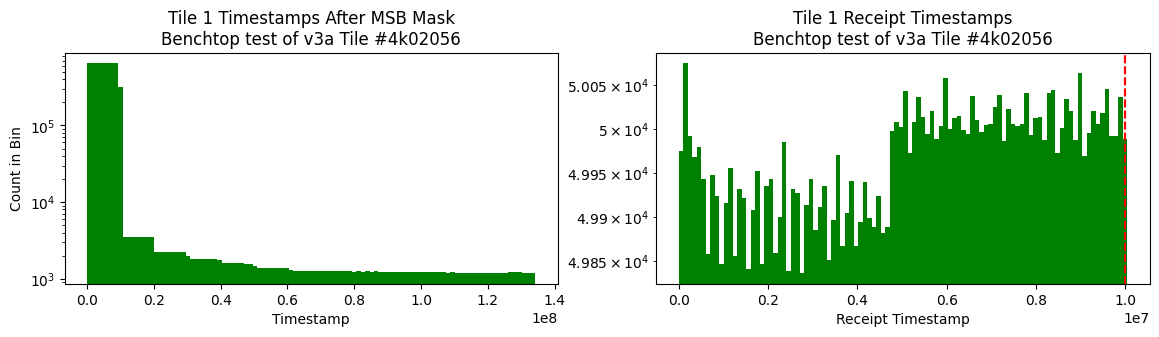

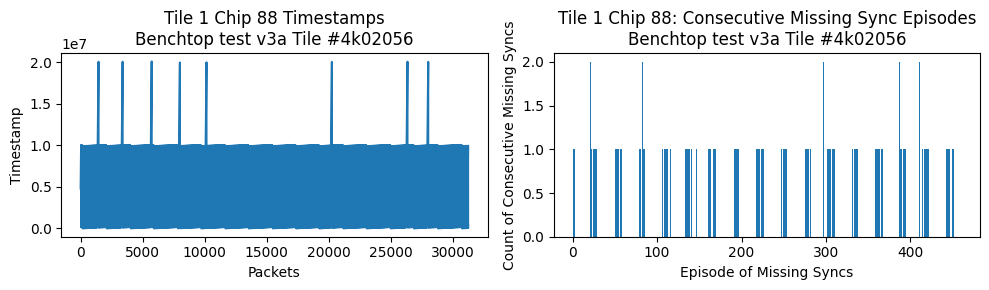

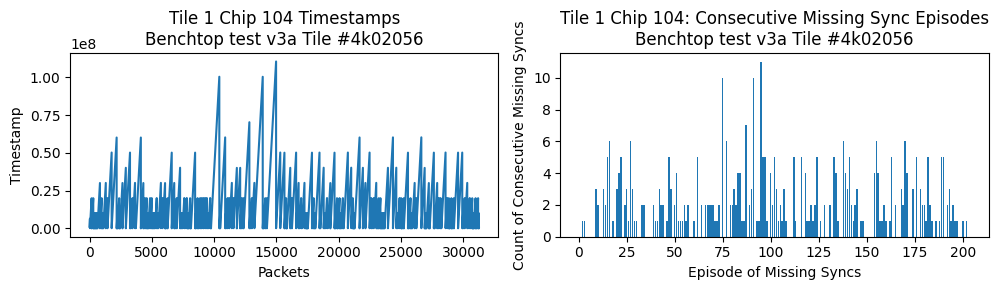

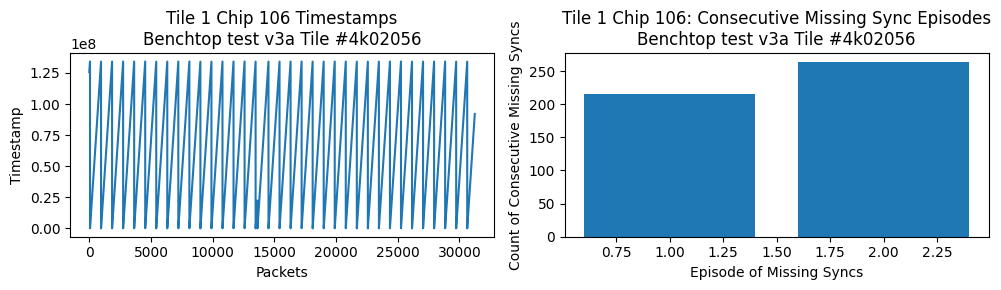

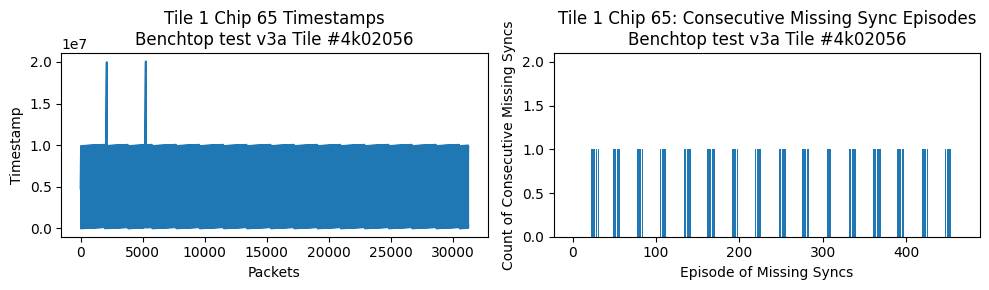

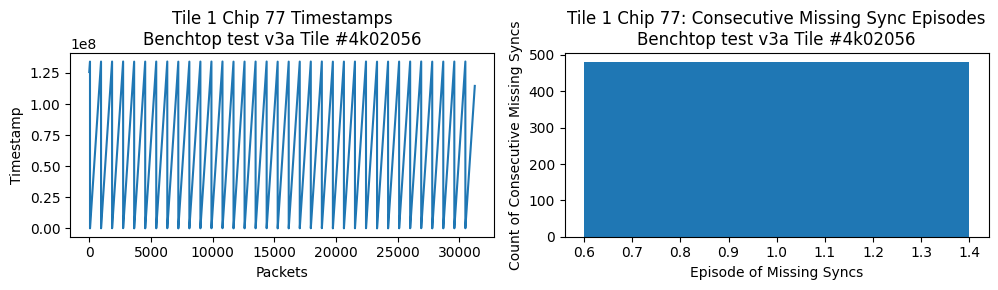

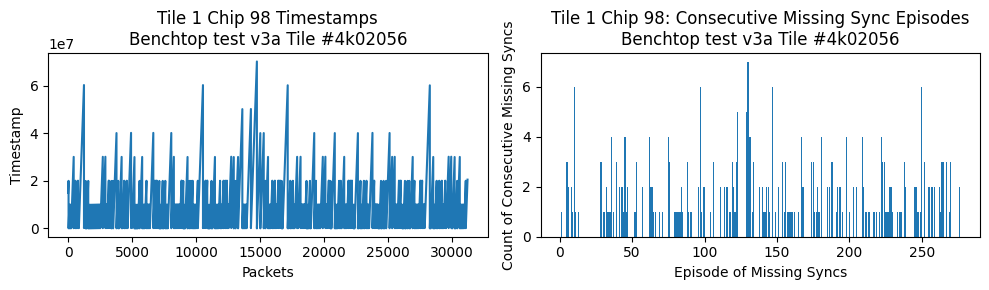

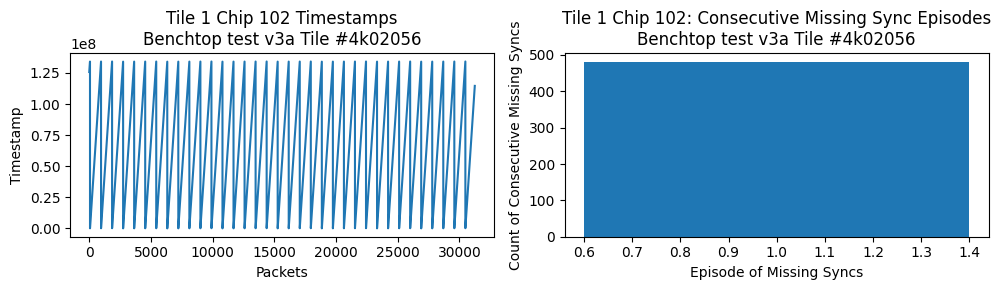

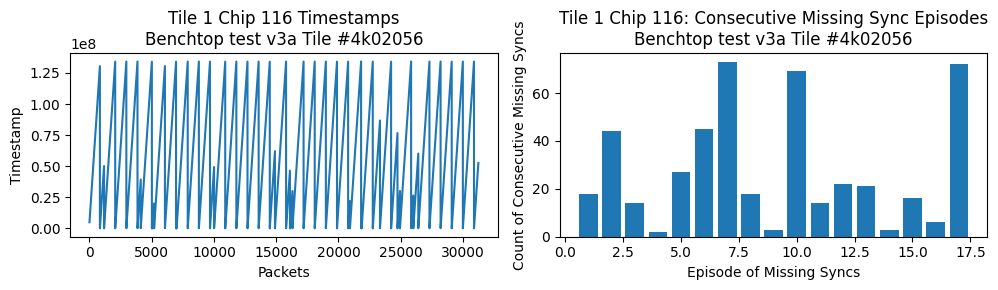

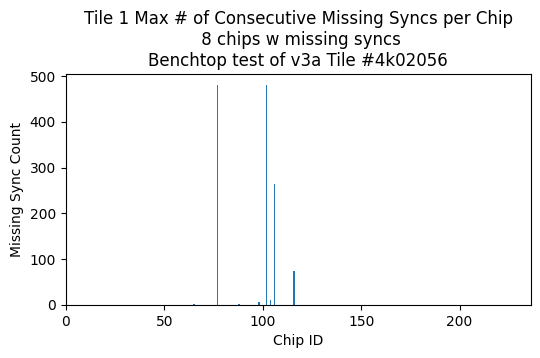

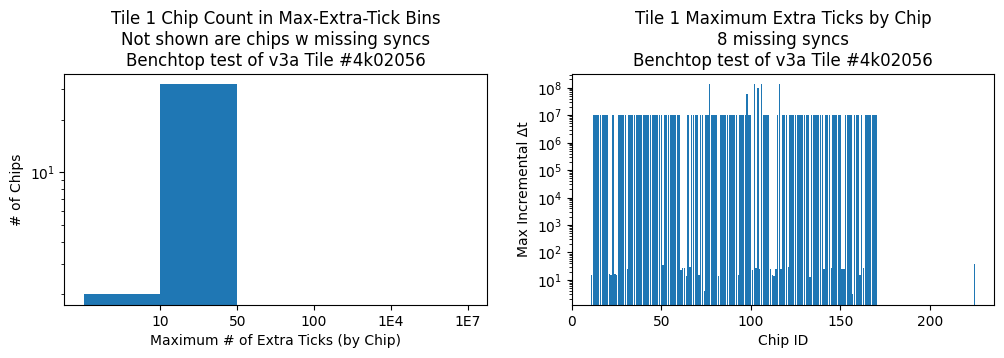

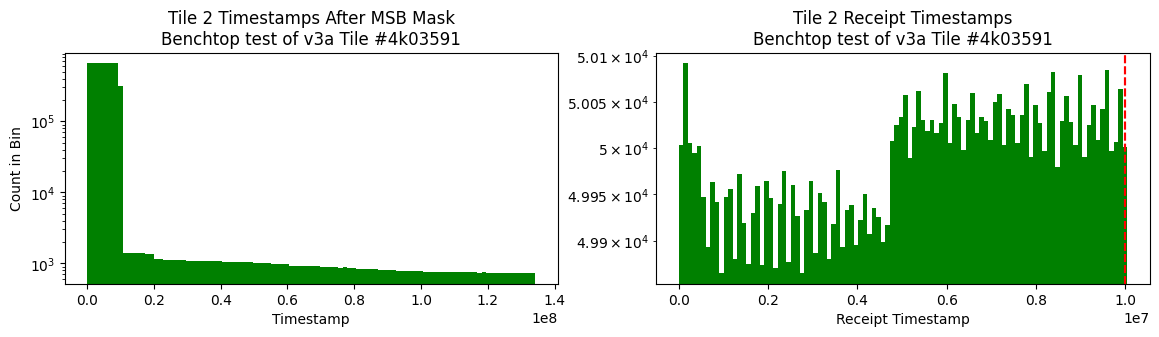

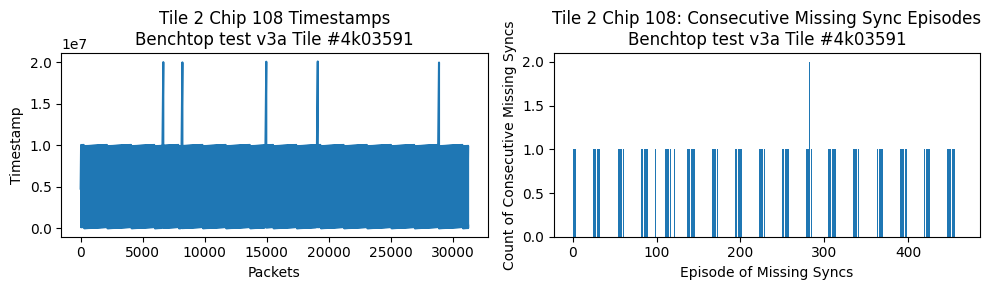

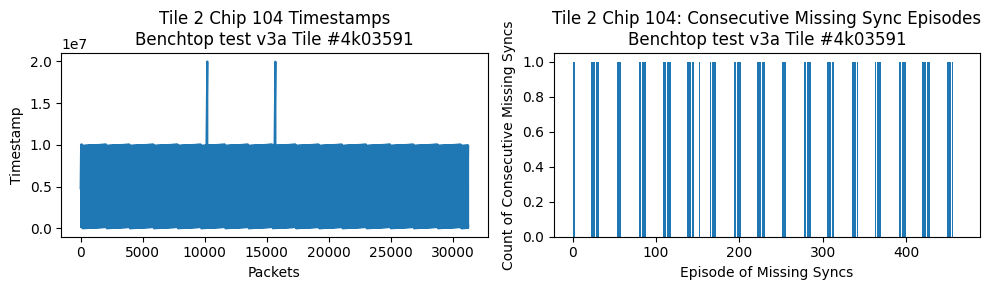

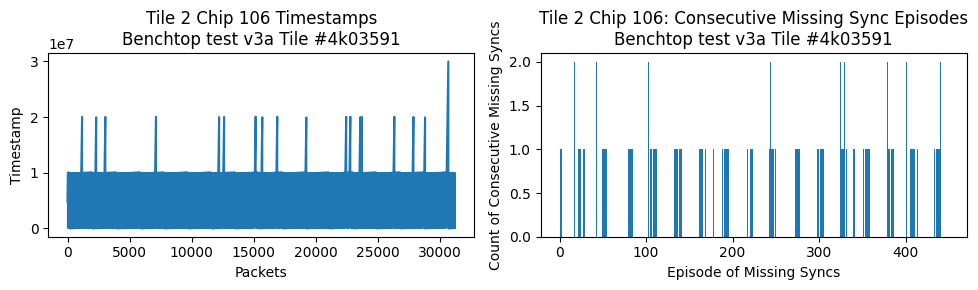

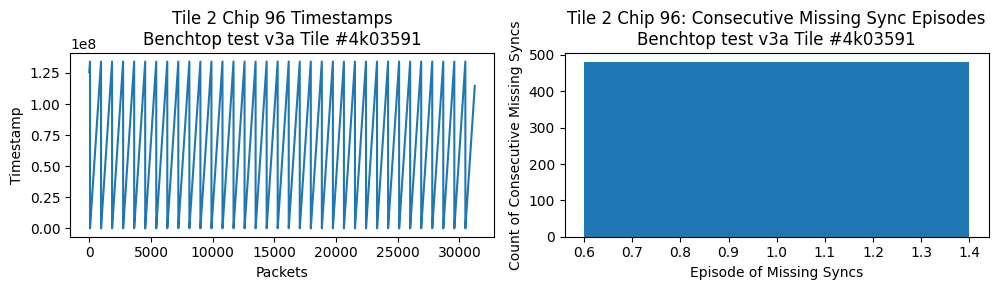

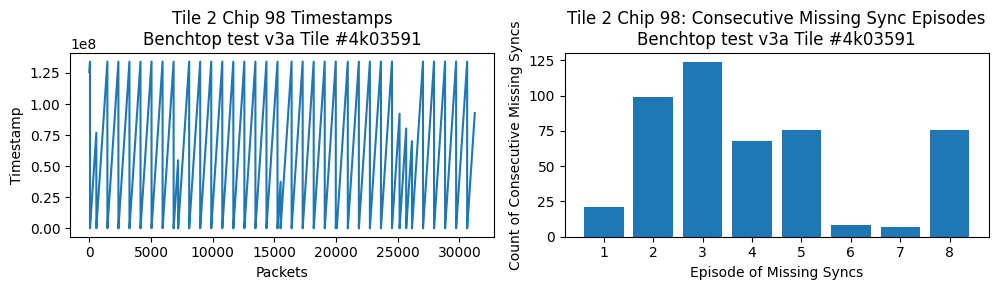

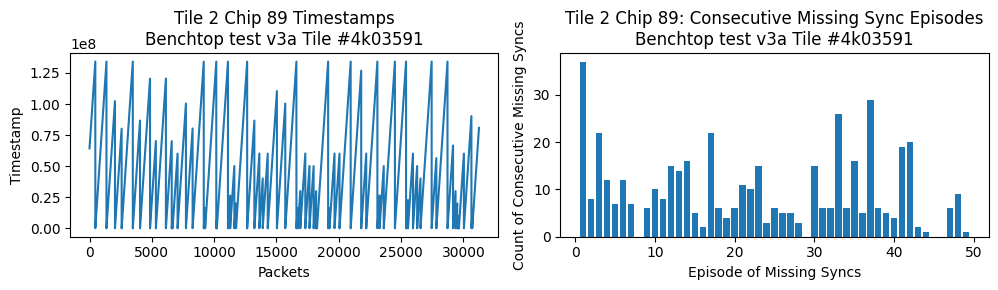

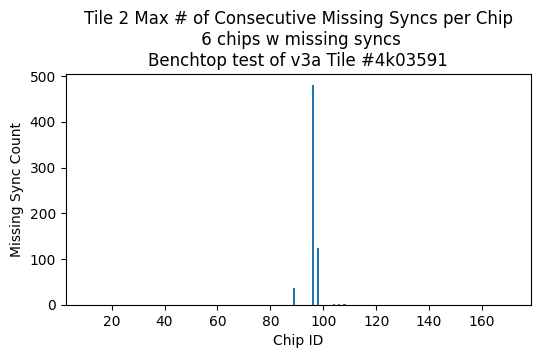

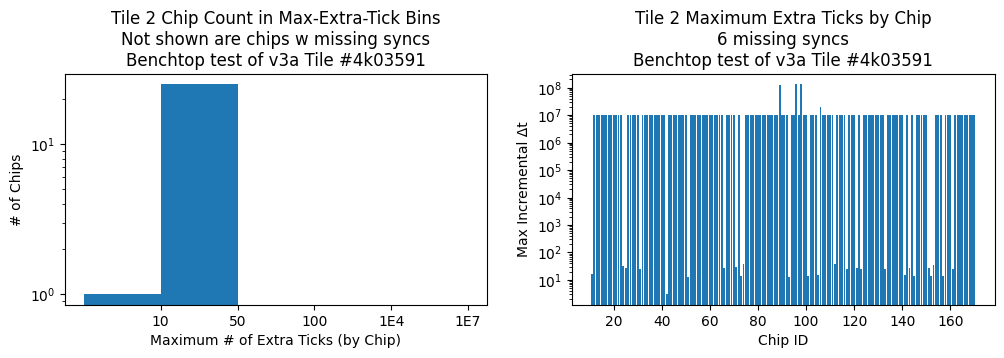

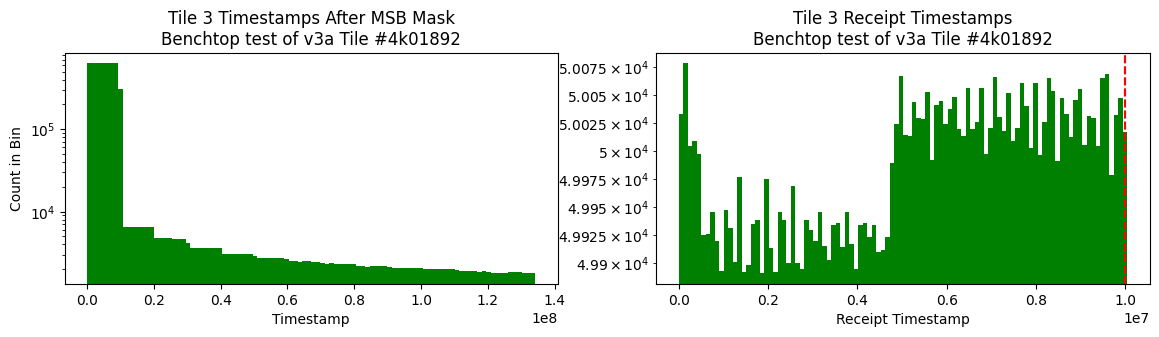

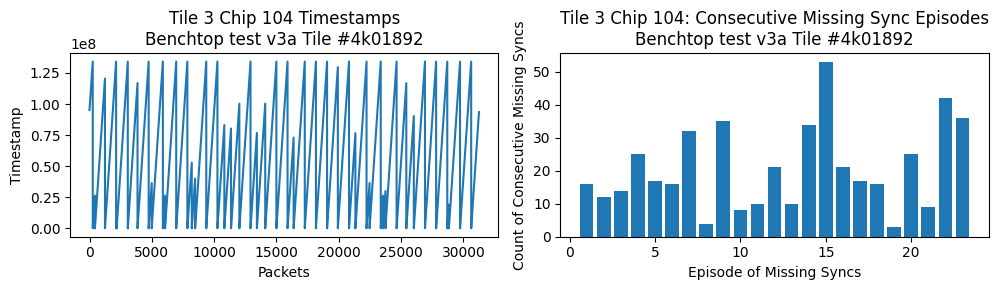

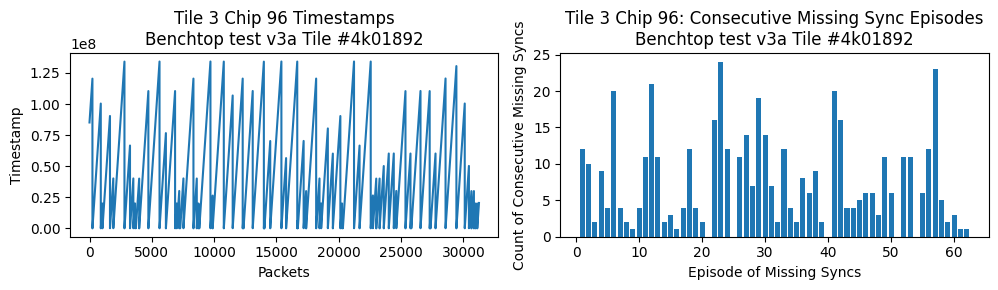

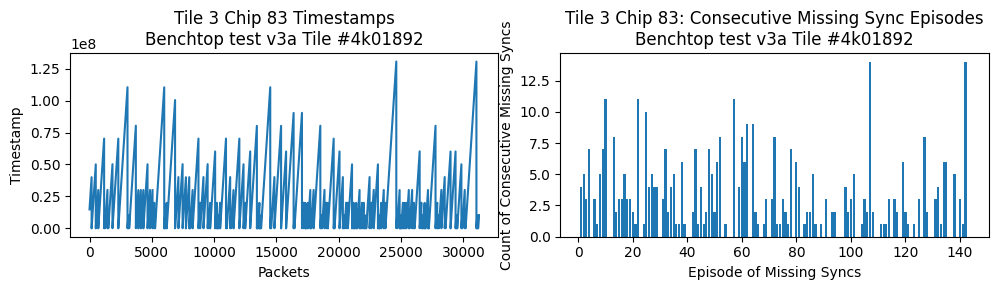

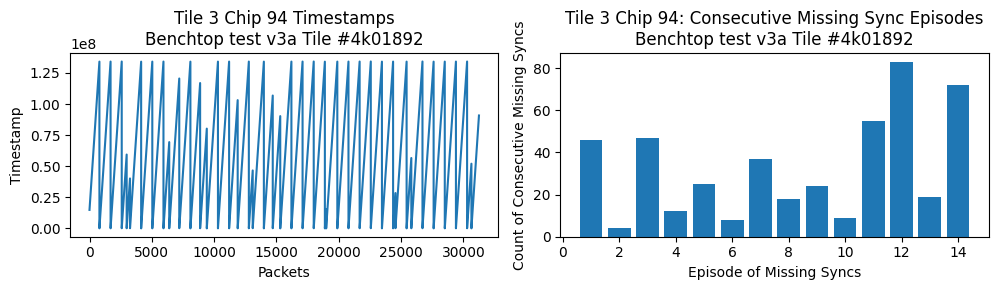

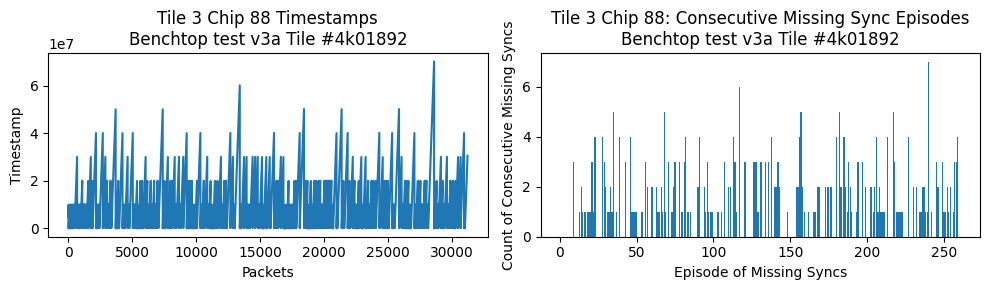

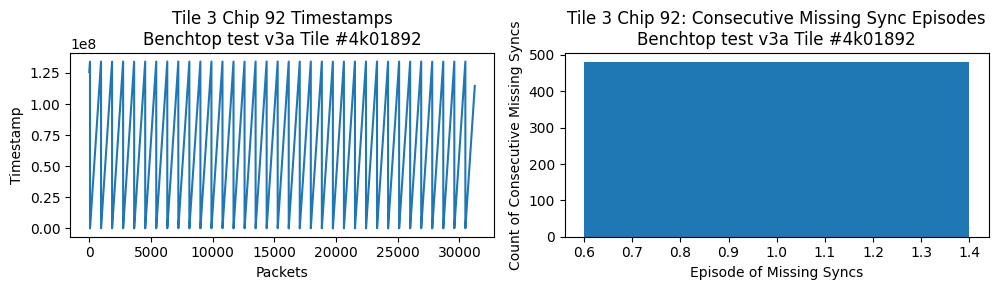

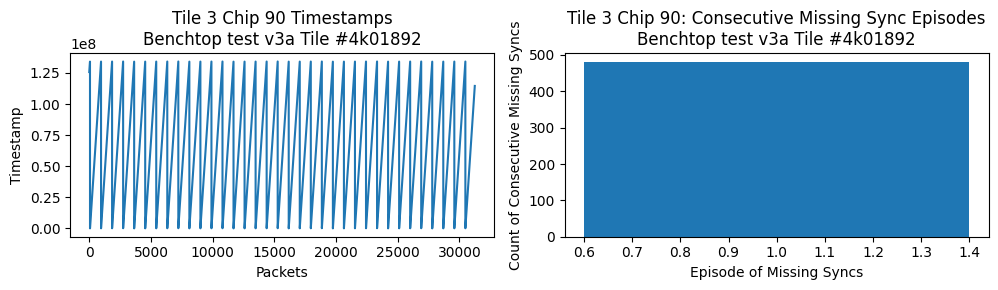

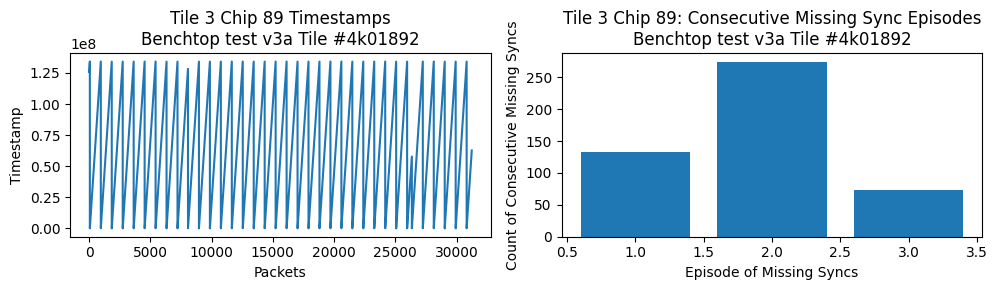

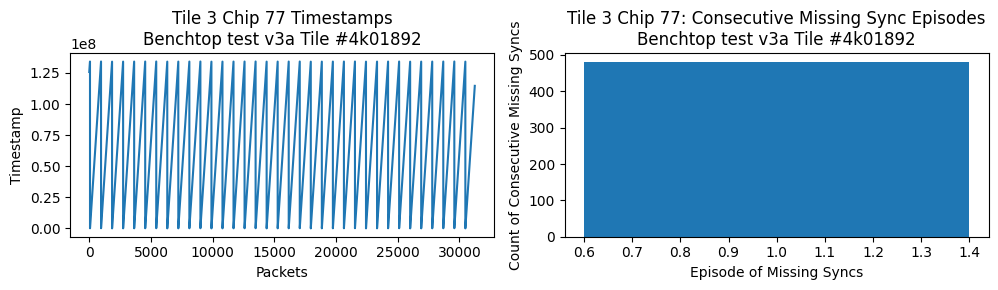

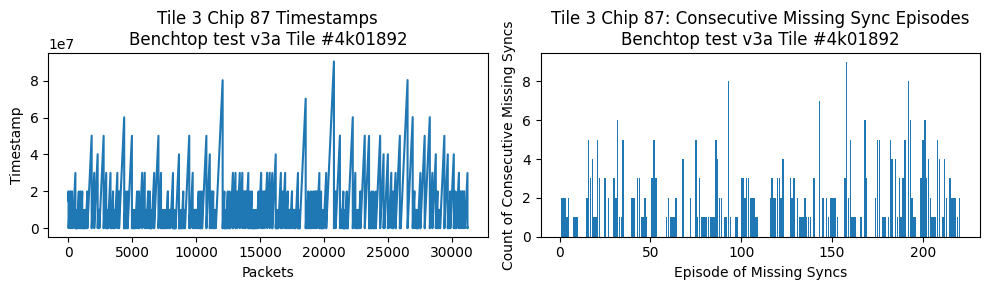

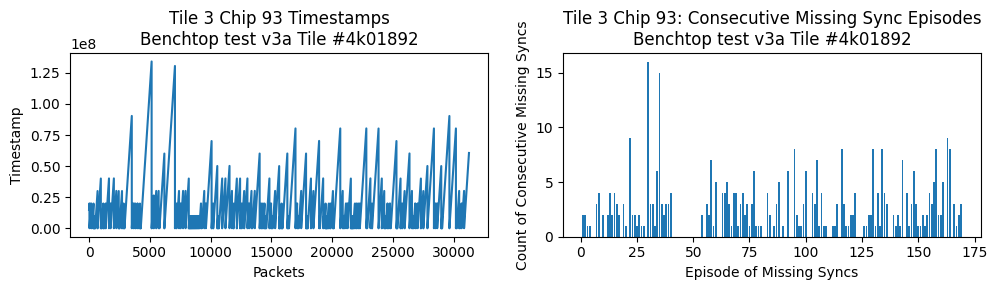

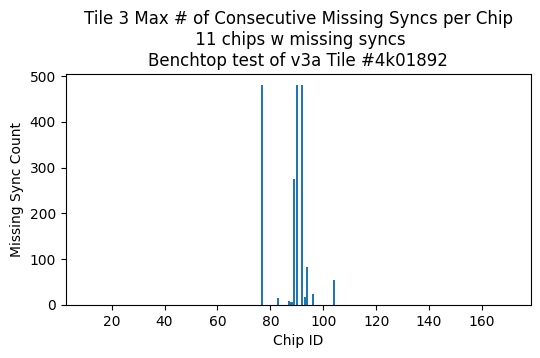

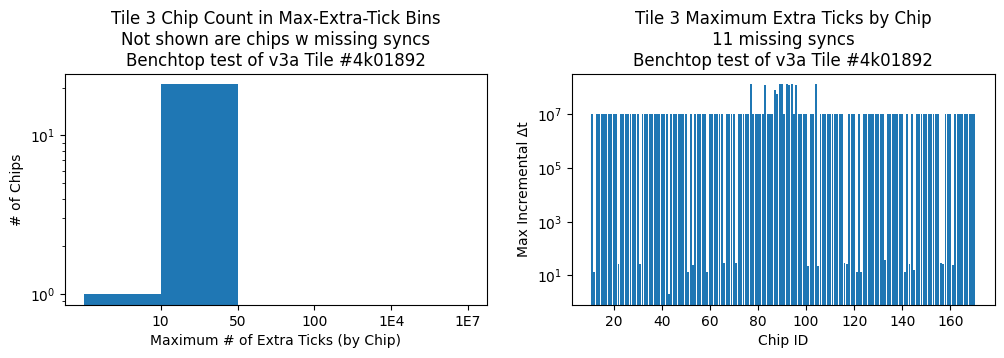

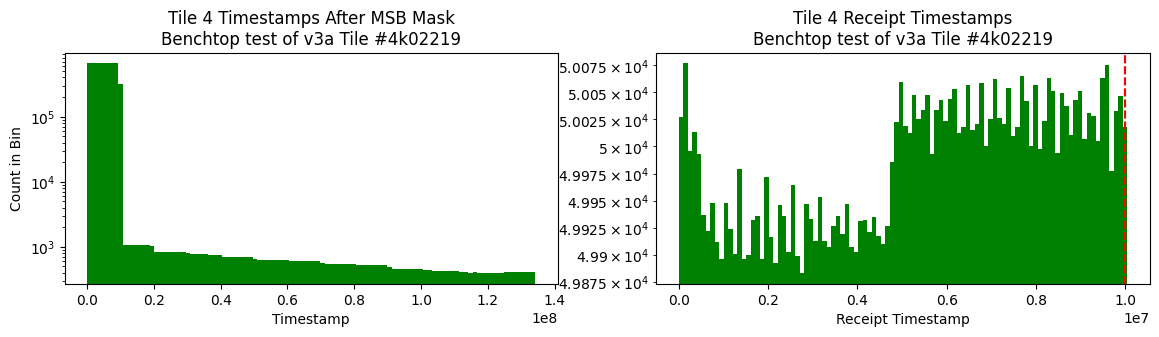

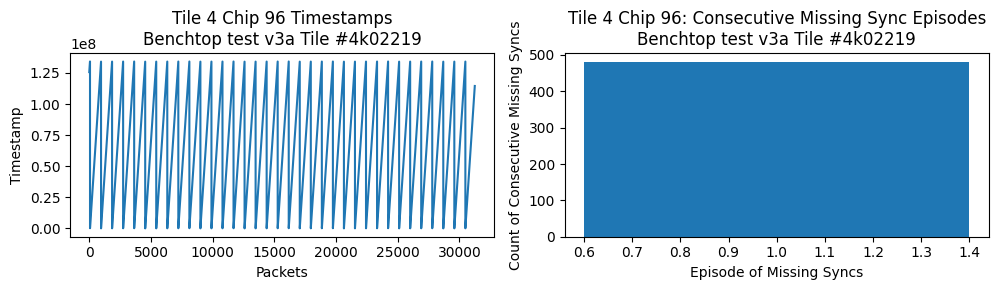

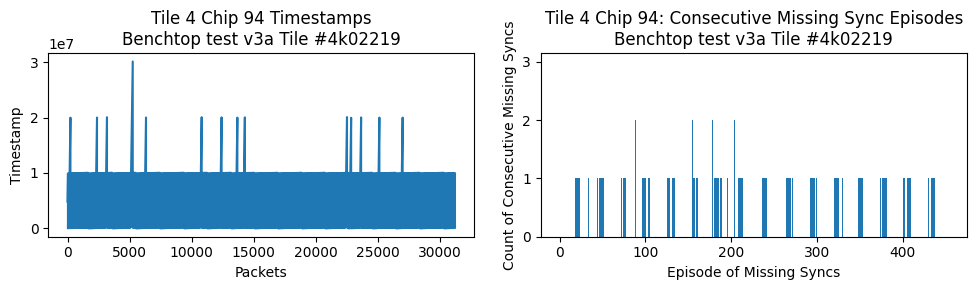

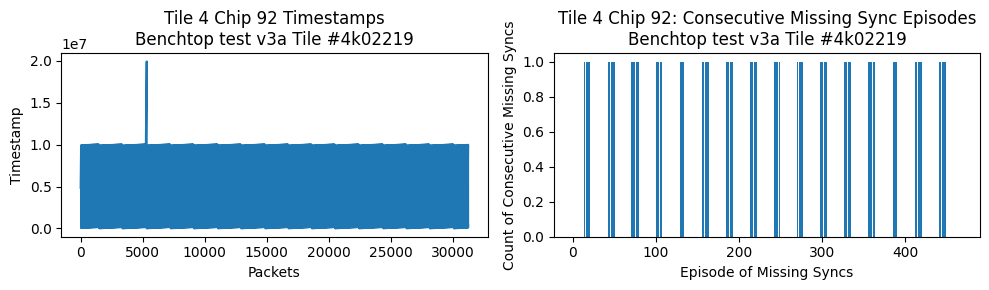

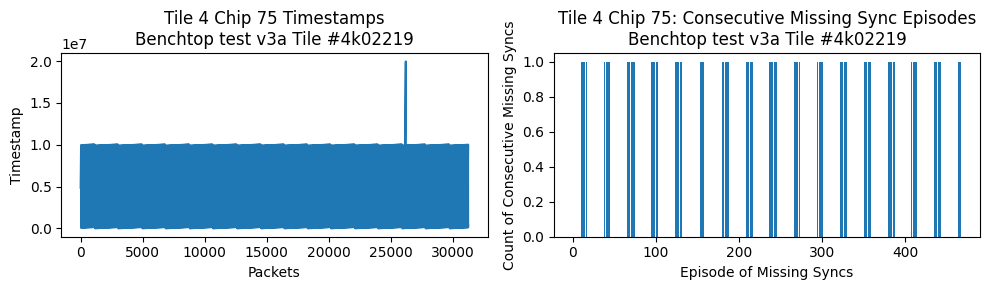

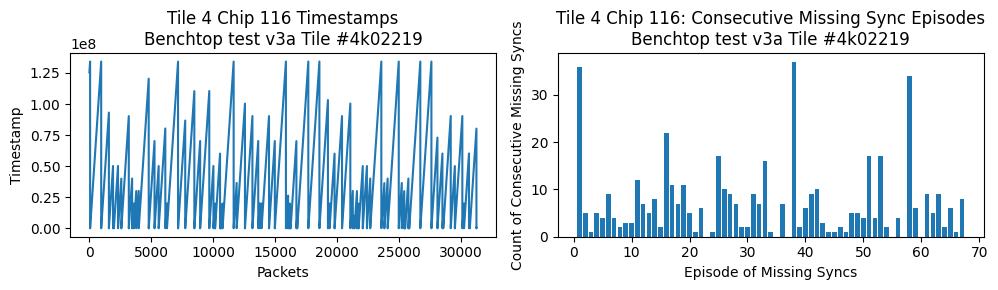

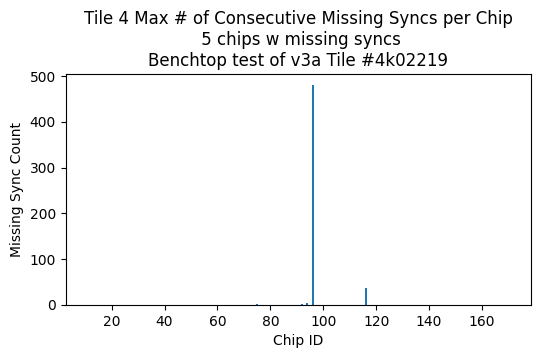

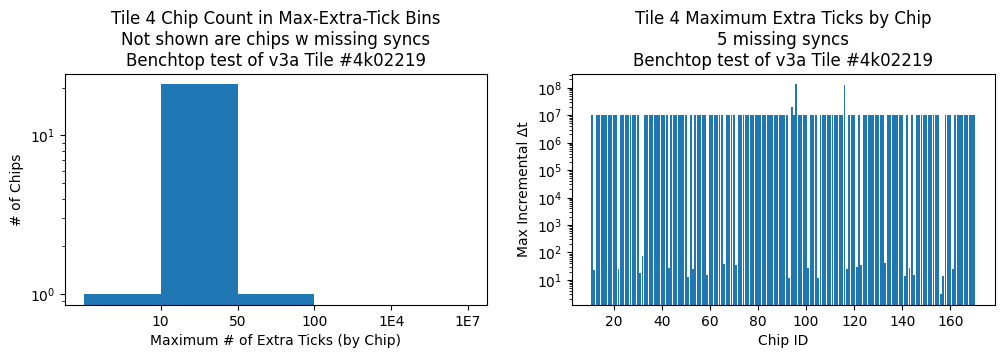

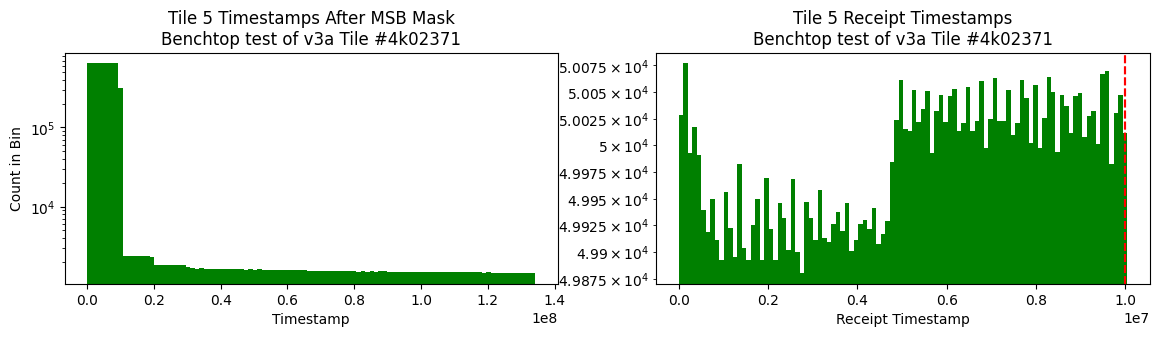

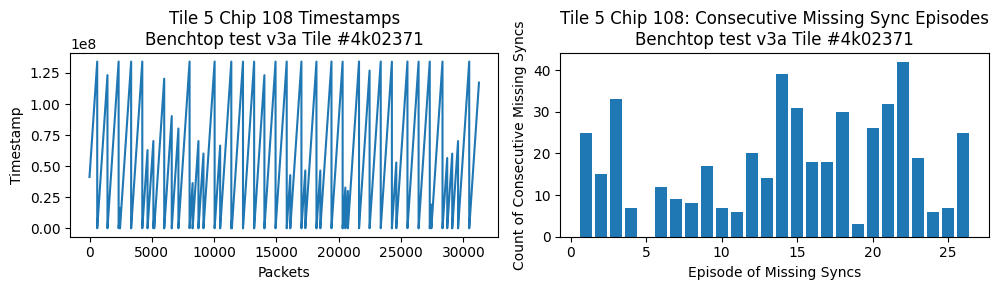

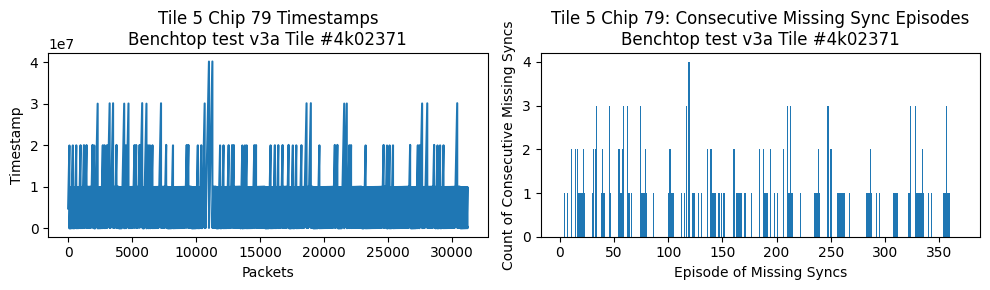

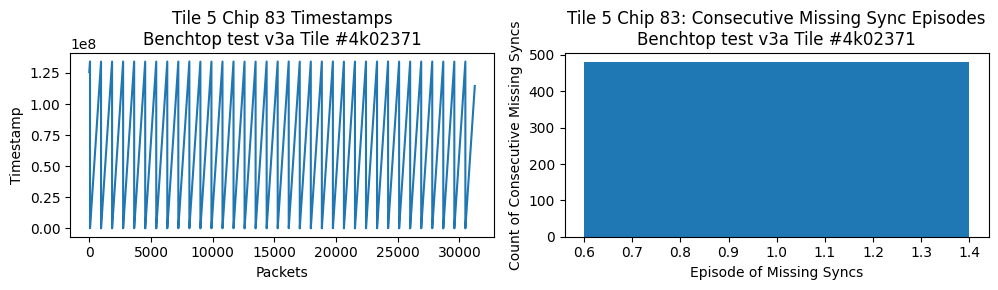

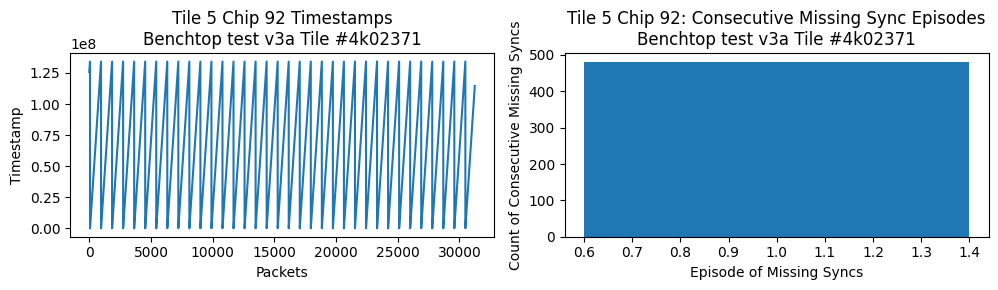

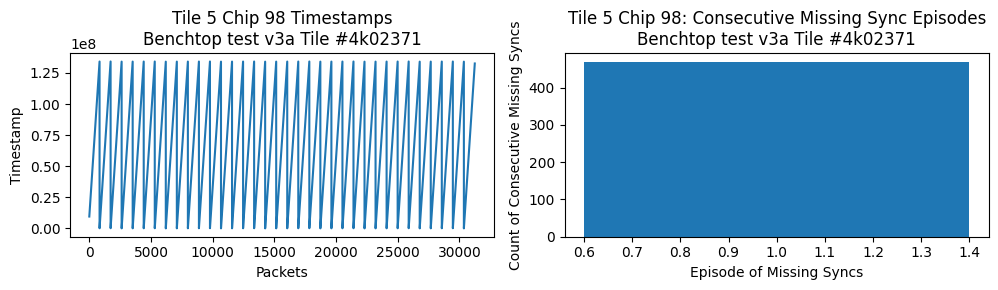

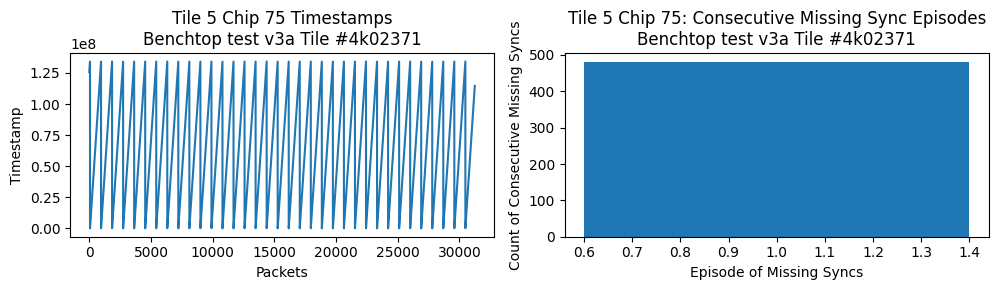

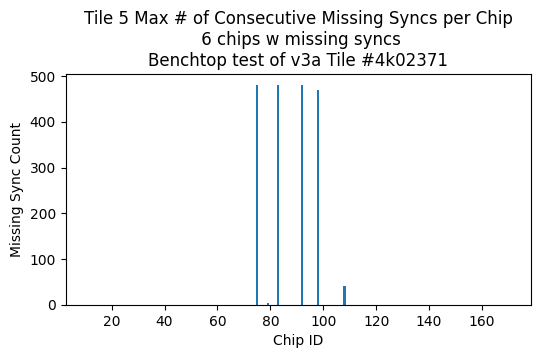

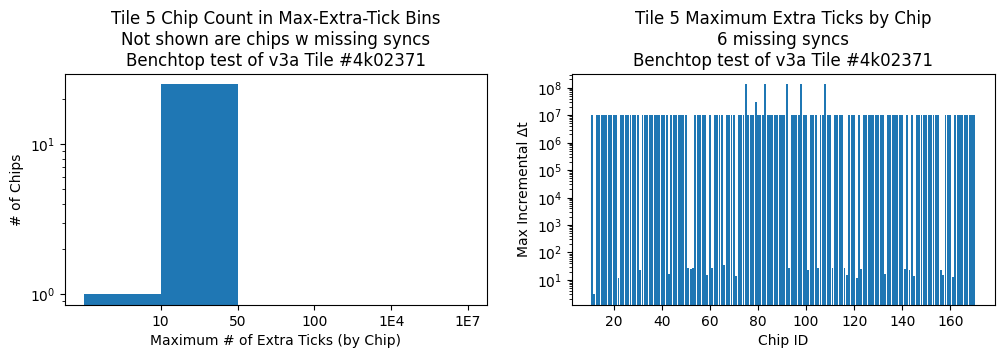

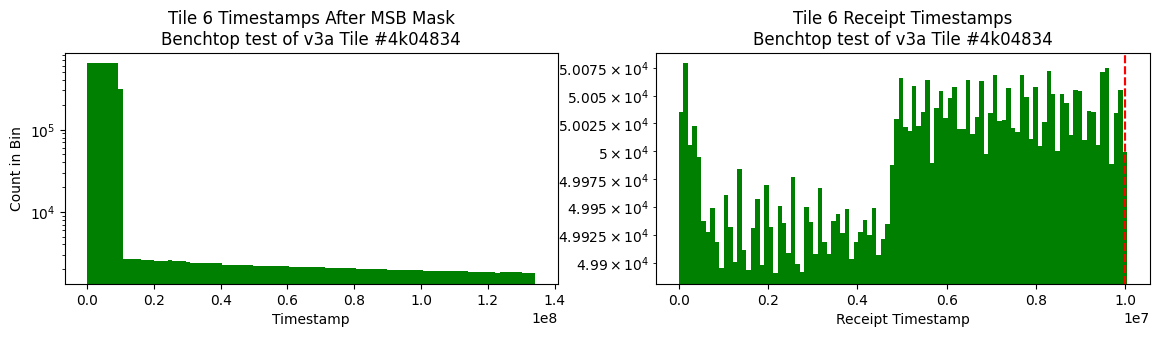

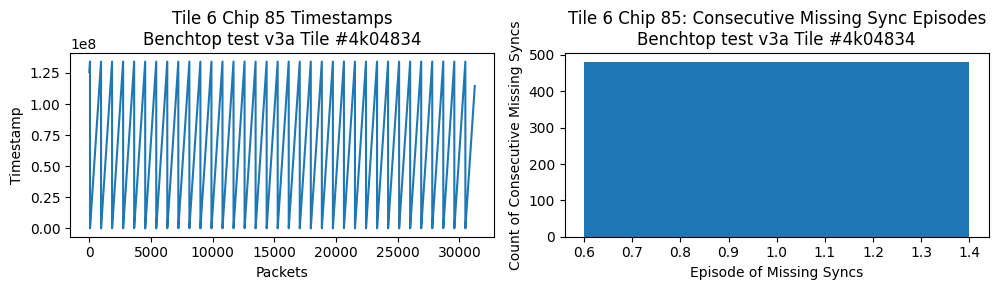

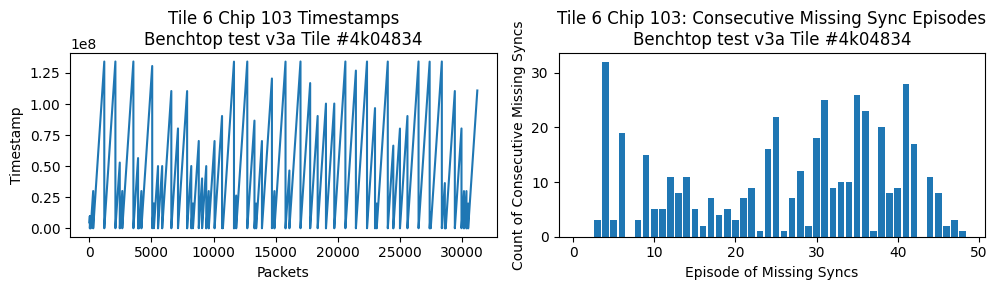

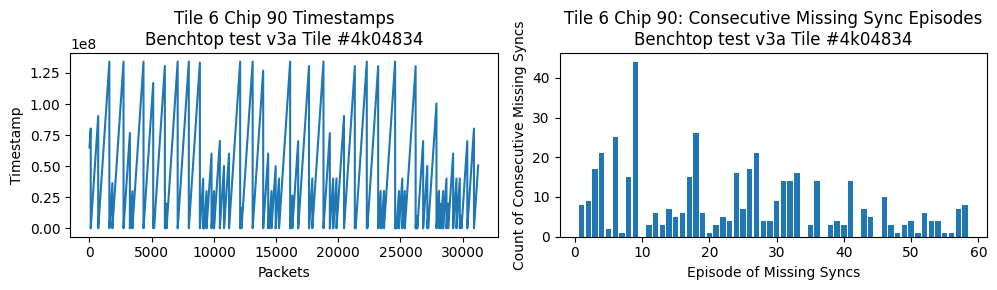

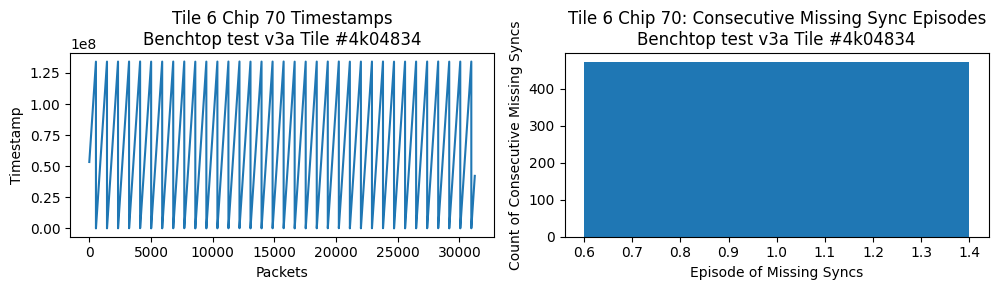

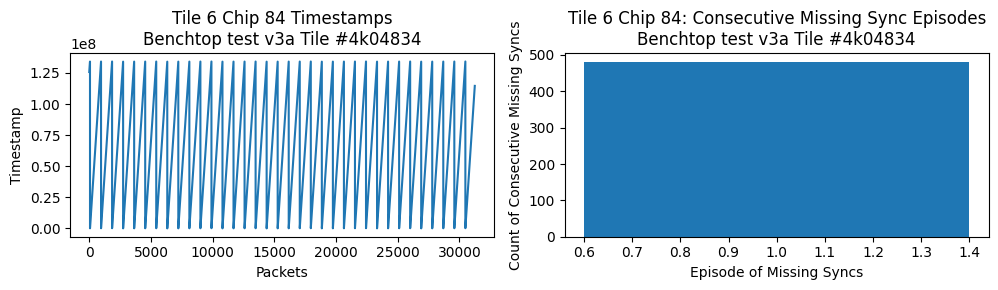

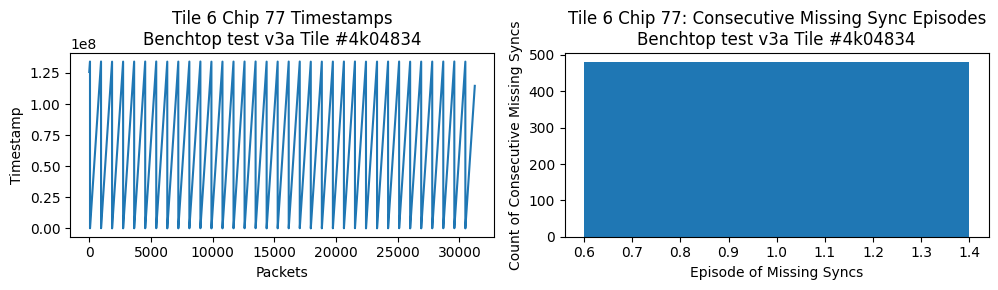

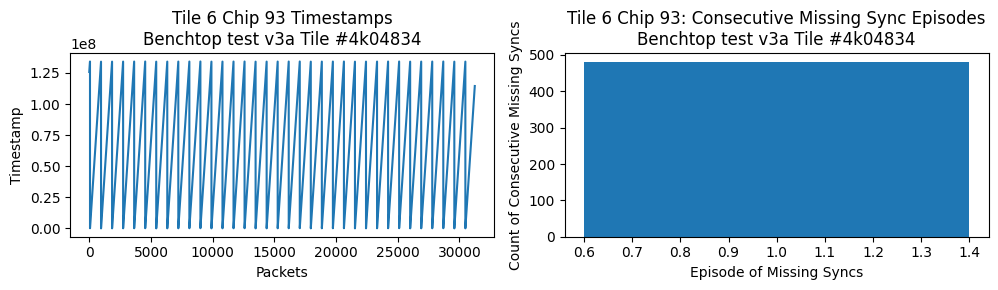

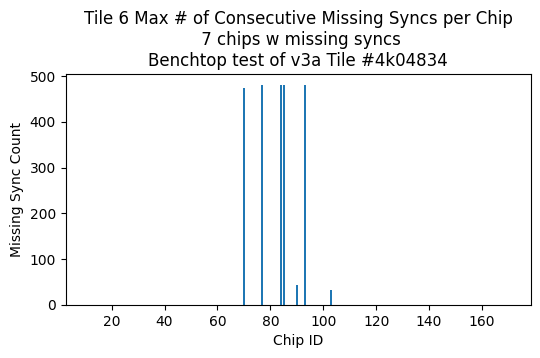

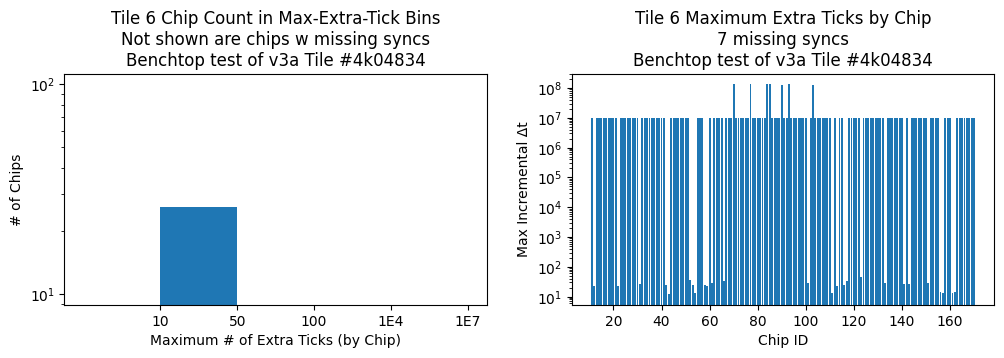

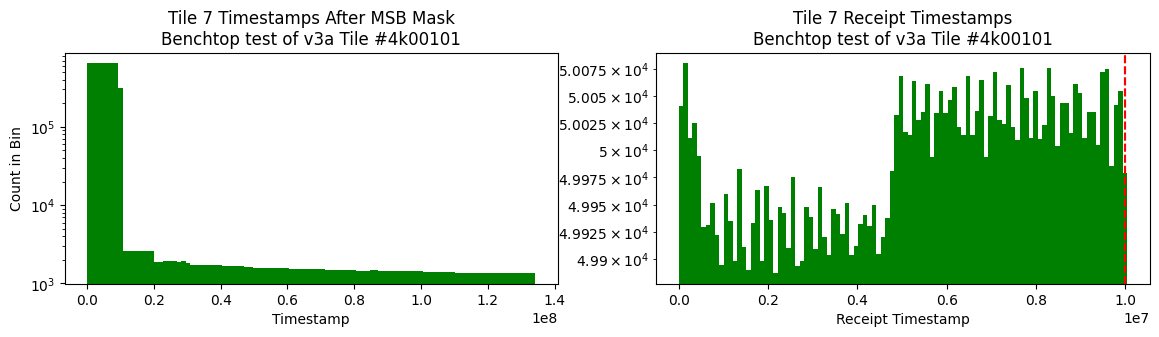

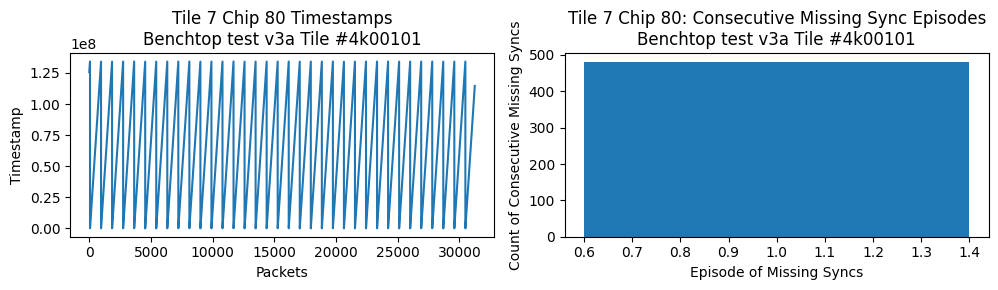

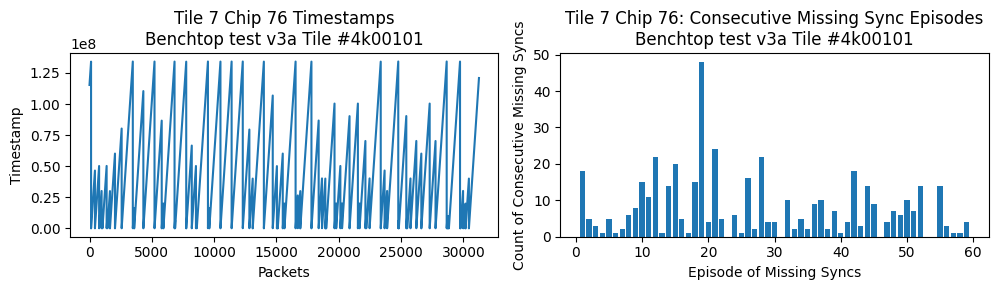

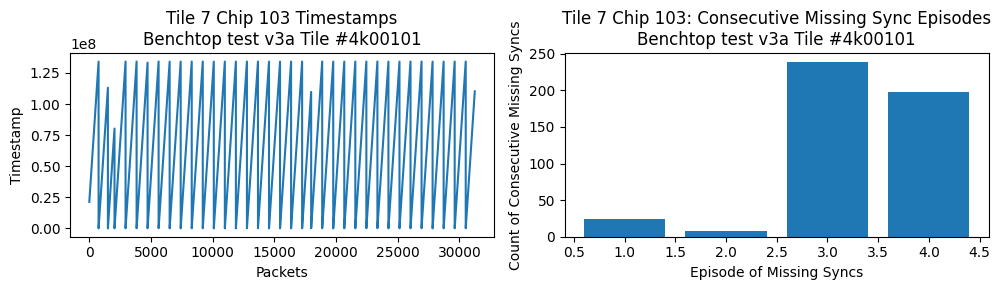

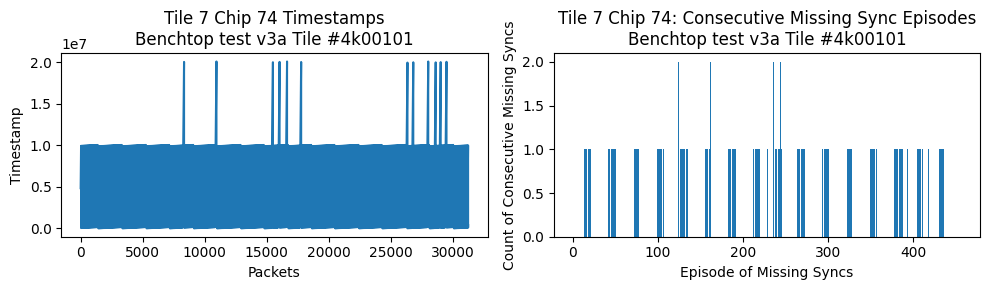

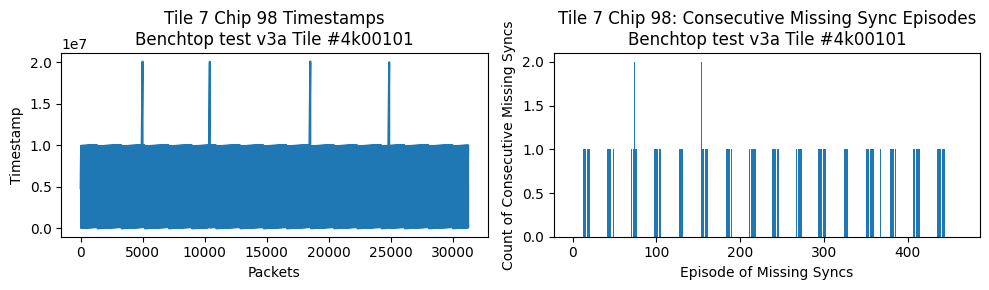

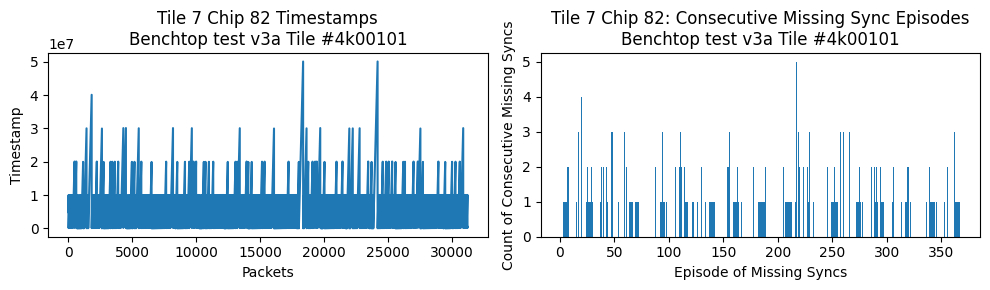

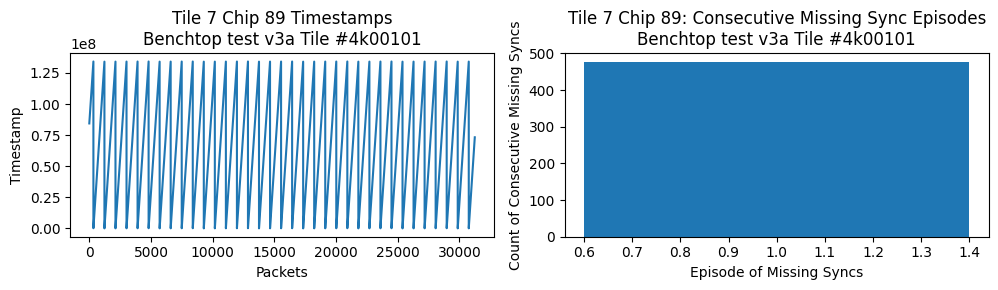

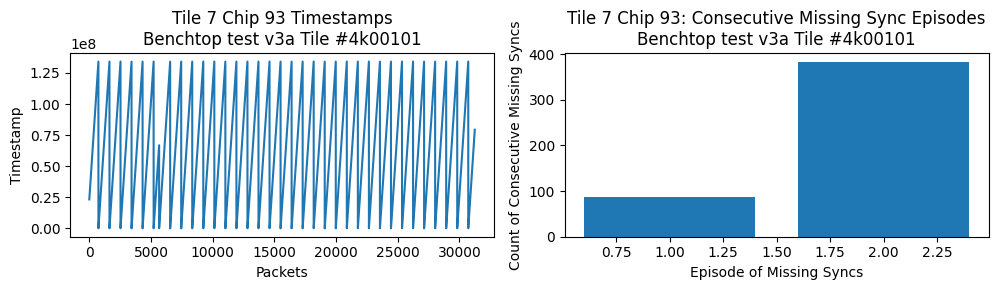

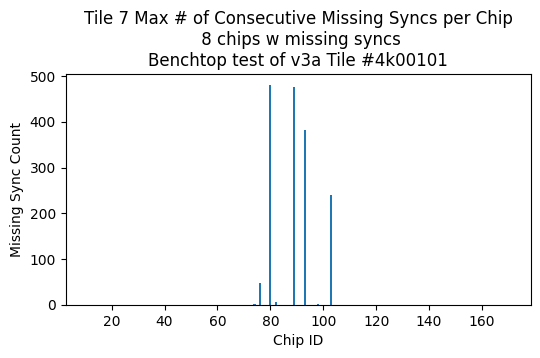

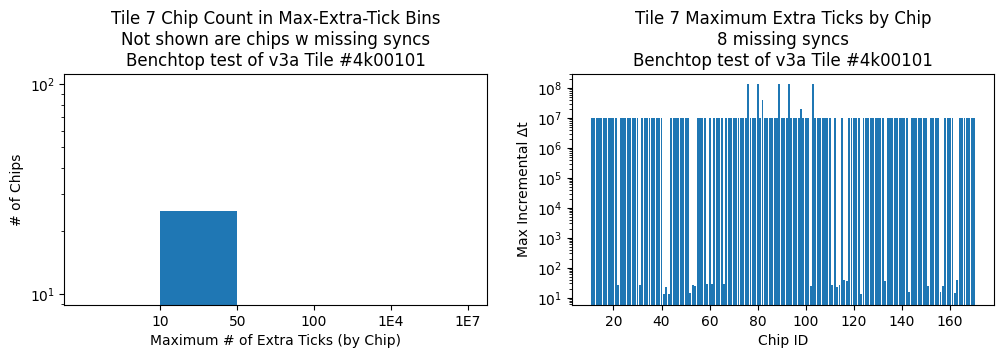

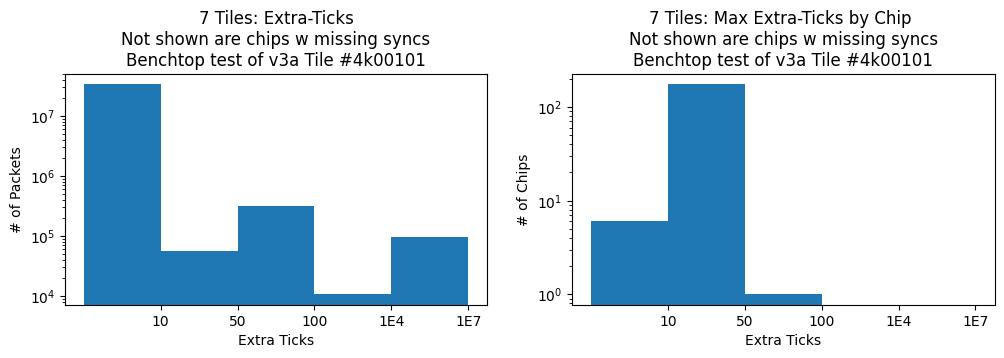

In [7]:
####################
# main
####################

print(f'Run Statistics:')

# get packets from the finename and check for missing syncs
for tile in tiles:

    # initialize
    chip_serial_number = chip_serial_number_list[tile]
    missing_sync_chip_count = 0
    missing_sync_chip_count, consecutive_missing_syncs, sync_chips, max_differences = 0, [], [], []
    max_10 = 0

    
    get_data(filename, tile, ig)

graph_all_tile(all_tile_incremental_diff, all_tile_max_differences)
